# Исследование стартапов

## Введение

### Цели и задачи проекта

**Цель:** Выявить закономерности финансирования стартапов и оценить перспективы выхода на рынок с покупкой и развитием компаний.

**Задачи:**
1. Загрузить предоставленные данные и познакомиться с ними;
2. Выполнить предобработку данных: выявить неточности и скорректировать их для дальнейшего анализа;
3. Провести исследовательский анализ данных:
   * Классифицировать сегменты рынка на массовые, средние и нишевые и учесть это в дальнейшем анализе; 
   * Определить типичные и аномальные значения объёмов финансирования, исключить выбросы и ограничить период исследования;
   * Сравнить популярность и объёмы разных типов финансирования;
   * Проанализировать динамику раундов и объёмов инвестиций по годам, а также изменения в массовых сегментах рынка;
   * Рассчитать долю возврата средств для разных типов финансирования и оценить её устойчивость;
4. Оформить вывод о проделанной работе и сформулировать рекомендации. 

### Описание данных

Для анализа поступили данные о компаниях, объёмах и типах привлечённых инвестиций, а также дополнительная статистика по возвратам средств.
. Данные состоят из двух датасетов:
    - `cb_investments.csv` содержит информацию о компаниях и состоявшемся финансировании;
    - `cb_returns.csv` содержит информацию об объёмах возвратов по годам и типам финансирования в миллионах долларов.
    
#### Описаниае датасета `cb_investments.csv`

- `name` — название компании;
- `homepage_url` — ссылка на сайт компании;
- `category_list` — категории, в которых работает компания. Указываются через |;
- `market` — основной рынок или отрасль компании;
- `funding_total_usd` — общий объём привлечённых инвестиций в долларах США;
- `status` — текущий статус компании, например, operating, closed и так далее;
- `country_code` — код страны, например USA;
- `state_code` — код штата или региона, например CA;
- `region` — регион, например SF Bay Area;
- `city` — город, в котором расположена компания;
- `funding_rounds` — общее число раундов финансирования;
- `participants` — число участников в раундах финансирования;
- `founded_at` — дата основания компании;
- `founded_month` — месяц основания в формате YYYY-MM;
- `founded_quarter` — квартал основания в формате YYYY-QN;
- `founded_year` — год основания;
- `first_funding_at` — дата первого финансирования;
- `mid_funding_at` — дата среднего по времени раунда финансирования;
- `last_funding_at` — дата последнего финансирования;
- `seed` — сумма инвестиций на посевной стадии;
- `venture` — сумма венчурных инвестиций;
- `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг;
- `undisclosed` — сумма финансирования нераскрытого типа;
- `convertible_note` — сумма инвестиций через конвертируемые займы;
- `debt_financing` — сумма долгового финансирования;
- `angel` — сумма инвестиций от бизнес-ангелов;
- `grant` — сумма полученных грантов;
- `private_equity` — сумма инвестиций в виде прямых (частных) вложений;
- `post_ipo_equity` — сумма финансирования после IPO;
- `post_ipo_debt` — сумма долгового финансирования после IPO;
- `secondary_market` — сумма сделок на вторичном рынке;
- `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг;
- `round_A — round_H` — сумма инвестиций в соответствующем раунде.

#### Описаниае датасета `cb_returns.csv`

- `year` — год возврата средств;
- `seed` — сумма возвратов от посевных инвестиций;
- `venture` — сумма возвратов от венчурных инвестиций;
- `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу;
- `undisclosed` — сумма возвратов нераскрытого типа;
- `convertible_note` — сумма возвратов через конвертируемые займы;
- `debt_financing` — сумма возвратов от долгового финансирования;
- `angel` — сумма возвратов бизнес-ангелам;
- `grant` — сумма возвратов по грантам;
- `private_equity` — сумма возвратов прямых (частных) вложений;
- `post_ipo_equity` — сумма возвратов от IPO;
- `post_ipo_debt` — сумма возвратов от долгового IPO;
- `secondary_market` — сумма возвратов от сделок на вторичном рынке;
- `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.

### 1.1. Общая информация

In [1]:
import pandas as pd 

import matplotlib.pyplot as plt

import numpy as np

In [2]:
df_invest = pd.read_csv("https://code.s3.yandex.net/datasets/cb_investments.zip", sep=';', low_memory=False)

In [3]:
df_return = pd.read_csv('https://code.s3.yandex.net/datasets/cb_returns.csv')

In [6]:
df_invest.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
df_invest.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

In [8]:
df_invest.isna().sum()

name                     4857
homepage_url             8305
category_list            8817
 market                  8817
 funding_total_usd       4856
status                   6170
country_code            10129
state_code              24133
region                  10129
city                    10972
funding_rounds           4856
participants            23821
founded_at              15740
founded_month           15812
founded_quarter         15812
founded_year            15740
first_funding_at         4856
mid_funding_at          24006
last_funding_at          4856
seed                     4856
venture                  4856
equity_crowdfunding      4856
undisclosed              4856
convertible_note         4856
debt_financing           4856
angel                    4856
grant                    4856
private_equity           4856
post_ipo_equity          4856
post_ipo_debt            4856
secondary_market         4856
product_crowdfunding     4856
round_A                  4856
round_B   

In [9]:
df_invest.isna().sum() / len(df_invest) * 100

name                     8.945740
homepage_url            15.296350
category_list           16.239363
 market                 16.239363
 funding_total_usd       8.943898
status                  11.364055
country_code            18.655837
state_code              44.448742
region                  18.655837
city                    20.208494
funding_rounds           8.943898
participants            43.874093
founded_at              28.990312
founded_month           29.122923
founded_quarter         29.122923
founded_year            28.990312
first_funding_at         8.943898
mid_funding_at          44.214830
last_funding_at          8.943898
seed                     8.943898
venture                  8.943898
equity_crowdfunding      8.943898
undisclosed              8.943898
convertible_note         8.943898
debt_financing           8.943898
angel                    8.943898
grant                    8.943898
private_equity           8.943898
post_ipo_equity          8.943898
post_ipo_debt 

In [10]:
df_return.head(15)

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.00,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.00,0.20,0.00
1,2001,2.88,23.49,0.00,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.00,0.46,0.00
2,2002,6.59,209.42,0.00,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.00,0.06,0.00
3,2003,7.74,233.86,0.00,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.00,0.08,0.00
4,2004,9.93,555.90,0.00,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.00,0.55,0.00
5,2005,26.60,2628.92,0.00,9.51,0.02,35.09,31.06,0.0,2.40,3.51,0.00,0.05,0.00
6,2006,61.81,3100.18,0.19,46.74,1.78,113.21,47.75,0.0,16.67,20.58,0.00,0.12,0.00
7,2007,70.41,3585.37,0.01,55.37,3.22,125.68,164.51,0.0,88.81,24.36,0.00,0.57,0.00
8,2008,89.72,2717.02,0.03,41.02,1.71,397.54,102.83,0.0,130.38,84.28,0.00,0.47,0.00
9,2009,160.21,2501.29,0.18,37.50,2.25,394.10,97.21,0.0,203.70,76.76,0.00,0.12,0.02


In [11]:
df_return.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


Познакомившись с обоими датасетами можно сделать следующие выводы по каждому из них:

1. Датасет `df_invest` содержит 54294 строк и 40 столбцов. 
- Датасет большой и содержит объемный пласт информации. 
- Названия столбцов, в целом, соответствуют их содержанию и приведены к корректному регистру. Единственное, в последних столбцах `round_A — round_H` содержатся заглавные буквы, что можно поправить. 
- Пропуски прослеживаются в каждом столбце, что странно, тк похоже, что часть строк полностью пустые и напоминают сбой автоматической загрузки или переноса данных. Более того, пропусков немалое кол-во, в 1/3 столбцов процент пропусков варьируется от 11% до 44%, что является значительной частью данных и просто удалить эти строки может быть ошибкой. Вохможно, в дальнейшей работе пропуски в столбце `name` будут мешать анализу и их нужно будет убрать, однако сейчас оставим пропуски, как есть.
- В большей части столбцов тип данных допустимый. В столбцах, хранящих инф-ю о дате, используется некорректный тип данных `object`, это нужно будет поправить; + `funding_total_usd` записан в типе `object`, хотя коректнее его преобразовать в тип `float`. 

2. Датасет `df_return` намного меньше и содержит всего 15 строк и 14 столбцов. Все столбцы названы корректно. Пропусков нет, а тип данных везде верный.

### 1.2. Предобработка данных

In [12]:
df_invest.columns

Index(['name', 'homepage_url', 'category_list', ' market ',
       ' funding_total_usd ', 'status', 'country_code', 'state_code', 'region',
       'city', 'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_A', 'round_B',
       'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H'],
      dtype='object')

In [13]:
df_invest.columns = df_invest.columns.str.lower().str.replace(' ','')

In [14]:
df_invest.columns

Index(['name', 'homepage_url', 'category_list', 'market', 'funding_total_usd',
       'status', 'country_code', 'state_code', 'region', 'city',
       'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_a', 'round_b',
       'round_c', 'round_d', 'round_e', 'round_f', 'round_g', 'round_h'],
      dtype='object')

In [15]:
df_return.columns

Index(['year', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed',
       'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding'],
      dtype='object')

In [16]:
df_invest['category_list'] = df_invest['category_list'].str.replace('|','_')

/tmp/ipykernel_672/731833626.py:1: FutureWarning: The default value of regex will change from True to False in a future version. In addition, single character regular expressions will*not* be treated as literal strings when regex=True.
  df_invest['category_list'] = df_invest['category_list'].str.replace('|','_')


In [17]:
df_invest['category_list']

0                                              _Education_
1                                                      NaN
2        _Business Services_Agriculture_Automotive_Inve...
3                                              _Education_
4                                              _Education_
                               ...                        
54289                                                  NaN
54290                                                  NaN
54291                                                  NaN
54292                                                  NaN
54293                                                  NaN
Name: category_list, Length: 54294, dtype: object

In [18]:
df_invest['funding_total_usd'] = df_invest['funding_total_usd'].str.replace(',','')

In [19]:
df_invest['funding_total_usd']

0         90000000 
1          2000000 
2          9000000 
3          7700000 
4           540000 
            ...    
54289           NaN
54290           NaN
54291           NaN
54292           NaN
54293           NaN
Name: funding_total_usd, Length: 54294, dtype: object

In [20]:
df_invest['funding_total_usd'] = pd.to_numeric(df_invest['funding_total_usd'], errors='coerce')

In [21]:
df_invest['funding_total_usd'] = df_invest['funding_total_usd'] / 1000000

In [22]:
df_invest.dtypes

name                     object
homepage_url             object
category_list            object
market                   object
funding_total_usd       float64
status                   object
country_code             object
state_code               object
region                   object
city                     object
funding_rounds          float64
participants            float64
founded_at               object
founded_month            object
founded_quarter          object
founded_year            float64
first_funding_at         object
mid_funding_at           object
last_funding_at          object
seed                    float64
venture                 float64
equity_crowdfunding     float64
undisclosed             float64
convertible_note        float64
debt_financing          float64
angel                   float64
grant                   float64
private_equity          float64
post_ipo_equity         float64
post_ipo_debt           float64
secondary_market        float64
product_

In [23]:
df_invest['founded_at']

0        1636-09-08
1        1785-01-01
2        1802-07-19
3        1817-01-01
4        1826-01-01
            ...    
54289           NaN
54290           NaN
54291           NaN
54292           NaN
54293           NaN
Name: founded_at, Length: 54294, dtype: object

In [24]:
df_invest['first_funding_at'] = pd.to_datetime(df_invest['first_funding_at'], errors='coerce')

In [25]:
df_invest['last_funding_at'] = pd.to_datetime(df_invest['last_funding_at'], errors='coerce')

In [26]:
df_invest.dtypes

name                            object
homepage_url                    object
category_list                   object
market                          object
funding_total_usd              float64
status                          object
country_code                    object
state_code                      object
region                          object
city                            object
funding_rounds                 float64
participants                   float64
founded_at                      object
founded_month                   object
founded_quarter                 object
founded_year                   float64
first_funding_at        datetime64[ns]
mid_funding_at                  object
last_funding_at         datetime64[ns]
seed                           float64
venture                        float64
equity_crowdfunding            float64
undisclosed                    float64
convertible_note               float64
debt_financing                 float64
angel                    

In [27]:
df_return = df_return.set_index('year')

In [28]:
df_return.head()

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


In [29]:
df_invest['category_list'] = df_invest['category_list'].fillna('не_указано')

In [30]:
df_invest['status'] = df_invest['status'].fillna('не_указано')

In [31]:
df_invest['country_code'] = df_invest['country_code'].fillna('не_указано')

In [32]:
df_invest['city'] = df_invest['city'].fillna('не_указано')

In [33]:
duplicated_rows = df_invest.duplicated().sum()

display(duplicated_rows)

4855

In [34]:
df_invest = df_invest.drop_duplicates(subset=None, keep='first', inplace=False)

In [35]:
duplicated_rows = df_invest.duplicated().sum()

display(duplicated_rows)

0

In [36]:
duplicated_rows2 = df_return.duplicated().sum()

display(duplicated_rows2)

0

In [37]:
df_invest = df_invest.dropna(subset=['funding_total_usd'])

In [38]:
df_invest.isna().sum()

name                        1
homepage_url             2314
category_list               0
market                   2503
funding_total_usd           0
status                      0
country_code                0
state_code              15288
region                   3819
city                        0
funding_rounds              0
participants            13576
founded_at               8706
founded_month            8772
founded_quarter          8772
founded_year             8706
first_funding_at            2
mid_funding_at          13676
last_funding_at             0
seed                        0
venture                     0
equity_crowdfunding         0
undisclosed                 0
convertible_note            0
debt_financing              0
angel                       0
grant                       0
private_equity              0
post_ipo_equity             0
post_ipo_debt               0
secondary_market            0
product_crowdfunding        0
round_a                     0
round_b   

In [39]:
df_invest['fund_interval'] = (df_invest['last_funding_at'] - df_invest['first_funding_at'])/2

In [40]:
df_invest['fund_interval']

0         0 days 00:00:00
1         0 days 00:00:00
2         0 days 00:00:00
3       173 days 12:00:00
4         0 days 00:00:00
               ...       
49433     0 days 00:00:00
49434     0 days 00:00:00
49435     0 days 00:00:00
49436     0 days 00:00:00
49437     0 days 00:00:00
Name: fund_interval, Length: 40907, dtype: timedelta64[ns]

In [41]:
df_invest['mid_funding_at'] = df_invest['mid_funding_at'].fillna(df_invest['first_funding_at'] + df_invest['fund_interval'])

In [42]:
df_invest.isna().sum() 

name                        1
homepage_url             2314
category_list               0
market                   2503
funding_total_usd           0
status                      0
country_code                0
state_code              15288
region                   3819
city                        0
funding_rounds              0
participants            13576
founded_at               8706
founded_month            8772
founded_quarter          8772
founded_year             8706
first_funding_at            2
mid_funding_at              1
last_funding_at             0
seed                        0
venture                     0
equity_crowdfunding         0
undisclosed                 0
convertible_note            0
debt_financing              0
angel                       0
grant                       0
private_equity              0
post_ipo_equity             0
post_ipo_debt               0
secondary_market            0
product_crowdfunding        0
round_a                     0
round_b   

In [43]:
df_invest.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 40907 entries, 0 to 49437
Data columns (total 41 columns):
 #   Column                Non-Null Count  Dtype          
---  ------                --------------  -----          
 0   name                  40906 non-null  object         
 1   homepage_url          38593 non-null  object         
 2   category_list         40907 non-null  object         
 3   market                38404 non-null  object         
 4   funding_total_usd     40907 non-null  float64        
 5   status                40907 non-null  object         
 6   country_code          40907 non-null  object         
 7   state_code            25619 non-null  object         
 8   region                37088 non-null  object         
 9   city                  40907 non-null  object         
 10  funding_rounds        40907 non-null  float64        
 11  participants          27331 non-null  float64        
 12  founded_at            32201 non-null  object         
 13  f

In [44]:
df_invest.isna().sum() / len(df_invest) * 100

name                     0.002445
homepage_url             5.656734
category_list            0.000000
market                   6.118757
funding_total_usd        0.000000
status                   0.000000
country_code             0.000000
state_code              37.372577
region                   9.335810
city                     0.000000
funding_rounds           0.000000
participants            33.187474
founded_at              21.282421
founded_month           21.443763
founded_quarter         21.443763
founded_year            21.282421
first_funding_at         0.004889
mid_funding_at           0.002445
last_funding_at          0.000000
seed                     0.000000
venture                  0.000000
equity_crowdfunding      0.000000
undisclosed              0.000000
convertible_note         0.000000
debt_financing           0.000000
angel                    0.000000
grant                    0.000000
private_equity           0.000000
post_ipo_equity          0.000000
post_ipo_debt 

In [45]:
start_row_count = len(df1)

display(f'Количество строк до правок: {start_row_count}')

final_row_count = len(df_invest)

display(f'Количество строк после правок: {final_row_count}')

dif = start_row_count - final_row_count

display(f'Количество удаленных строк: {dif}')

dif_part = round((dif / start_row_count),2)

display(f'Доля удаленных строк: {dif_part}')

'Количество строк до правок: 54294'

'Количество строк после правок: 40907'

'Количество удаленных строк: 13387'

'Доля удаленных строк: 0.25'

В ходе знакомства с данными были обнаружены и устранены следующие неточности:

Данный были предоставлены в двух датасетах: `df_invest` и `df_return`. Датасет `df_invest` по объему данных сильно превосходил `df_return` и содержал более 50000 строк, когда `df_return` насчитывал всего 15 строк. Данные в `df_return` были хорошего качеста и полностью готовы к работе, только сделали столбец `year` индексом всего датасета. В свою очередь `df_invest` был ряд неточетов:

- Названия столбцов совпадали с их содержанием и были отображены в одном стиле. Только в столбцах `round_A — round_H` была необходимость замены заглавных букв на прописные, что было выполнено.
- В большей части столбцов тип данных был корректный; был изменены типы данных в столбцах с инф-ей о дате и времени на `datetime64[ns]` и `funding_total_usd` на числовой.
- Пропусков в `df_invest` было существенное количество и в каждом столбце. Часть данных не будет влиять на анализ, поэтому пропуски в них оставили как есть. Часть пропусков ушла после удаления явных дубликатов, их было 4855. Пропуски в столбце `mid_funding_at` были заполнены с помощью значений в столбцах `first_funding_at` и `last_funding_at`. Также, пропуски в текстовых столбцах были заполнены заглушками.

В итоге, всего было обработано 25% данных: часть из них исправлена, часть удалена. Сейчас данные выглядят готовыми к работе и их объем достаточный для проведения исследования: более 40000 строк.

### 2.1. Группы по срокам финансирования

Разделим все компании на три группы:

* Единичное финансирование — был всего один раунд финансирования.

* Срок финансирования до года — между первым и последним раундом финансирования прошло не более года.

* Срок финансирования более года.

Визуализируем соотношение этих групп, создав два графика:

* По количеству компаний: Покажем, какой процент от общего числа компаний относится к каждой из трёх групп.
* По объёму инвестиций: Отобразим, какую долю от общего объёма привлечённых средств получила каждая группа.

In [46]:
df_invest['fund_interval'] = df_invest['last_funding_at'] - df_invest['first_funding_at']

In [47]:
df_invest['days'] = df_invest['fund_interval'].dt.days

In [48]:
def group(row):
    if row == 0.0:
        return 'Единичное финансирование'
    elif row <= 365.0:
        return 'Срок финансирования до года'
    elif row > 365.0:
        return 'Срок финансирования более года'
    else:
        'Нет данных'

In [49]:
df_invest['groups'] = df_invest['days'].apply(group)

In [50]:
df_invest['groups']

0           Единичное финансирование
1           Единичное финансирование
2           Единичное финансирование
3        Срок финансирования до года
4           Единичное финансирование
                    ...             
49433       Единичное финансирование
49434       Единичное финансирование
49435       Единичное финансирование
49436       Единичное финансирование
49437       Единичное финансирование
Name: groups, Length: 40907, dtype: object

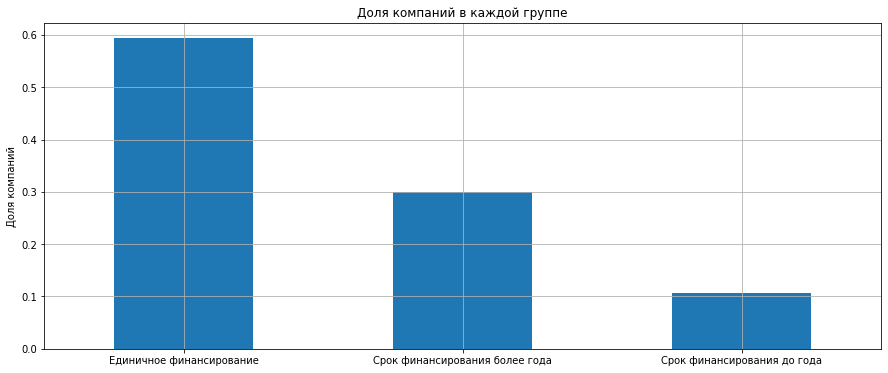

In [51]:
df_invest['groups'].value_counts(normalize=True).plot(kind='bar',
                                                      title='Доля компаний в каждой группе',
                                                      ylabel='Доля компаний',
                                                      xlabel='',
                                                      rot=0,    
                                                      figsize=(15, 6))   

plt.grid()
plt.show()

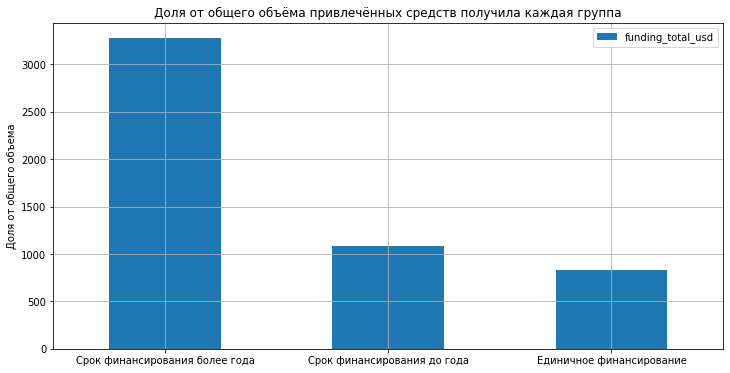

In [52]:
grouped = df_invest.groupby('groups')['funding_total_usd'].mean()

grouped = grouped * 100

grouped = grouped.sort_values(ascending=False)

grouped.plot(kind='bar',
             title=f'Доля от общего объёма привлечённых средств получила каждая группа',
             legend=True,
             ylabel='Доля от общего объема',
             xlabel='',
             rot=0,
             figsize=(12, 6))

plt.grid() 

plt.show()

### 2.2 Выделение средних и нишевых сегментов рынка

Рассчитаем, как часто в датасете встречается каждый из сегментов рынка. Сегменты, к которым относится более 120 компаний, отнесем к массовым, сегменты, в которые входит от 35 до 120 включительно, отнесем к средним, а сегменты до 35 компаний отнесем к нишевым. Рассчитаем, сколько сегментов попадает в каждую из категорий.

Построим график распределения количества компаний в сегментах и отобразим на нём разделение на нишевые и средние сегменты.

In [53]:
df_invest['market'] = df_invest['market'].str.lower().str.replace(' ','')

In [54]:
market_count = df_invest['market'].value_counts()

display(market_count)

software                4812
biotechnology           3590
mobile                  2344
e-commerce              1866
curatedweb              1693
                        ... 
spacetravel                1
professionalservices       1
forums                     1
businessanalytics          1
nightlife                  1
Name: market, Length: 394, dtype: int64

In [55]:
def segment(row):
    if row < 35:
        return 'Нишевые'
    elif 35 <= row <= 120:
        return 'Средние'
    elif row > 120:
        return 'Массовые'
    else:
        'Нет данных'

In [56]:
segments = market_count.apply(segment)
display(segments.unique())

array(['Массовые', 'Средние', 'Нишевые'], dtype=object)

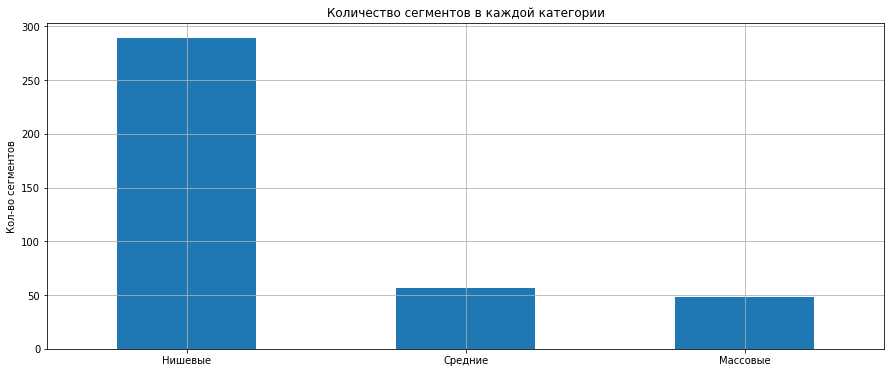

In [57]:
segments.value_counts().plot(kind='bar',
                             title='Количество сегментов в каждой категории',
                             ylabel='Кол-во сегментов',
                             xlabel='',
                             rot=0,    
                             figsize=(15, 6))   

plt.grid()
plt.show()

In [58]:
df_invest['market_counts'] = df_invest.groupby('market')['market'].transform('count')


df_invest['market_category'] = pd.cut(df_invest['market_counts'], 
                                      bins=[0, 35, 120, float('inf')], 
                                      labels=['Нишевые', 'Средние', 'Массовые'], 
                                      right=False)

df_invest['market_category']

0        Массовые
1             NaN
2         Средние
3        Массовые
4        Массовые
           ...   
49433         NaN
49434     Нишевые
49435         NaN
49436         NaN
49437    Массовые
Name: market_category, Length: 40907, dtype: category
Categories (3, object): ['Нишевые' < 'Средние' < 'Массовые']

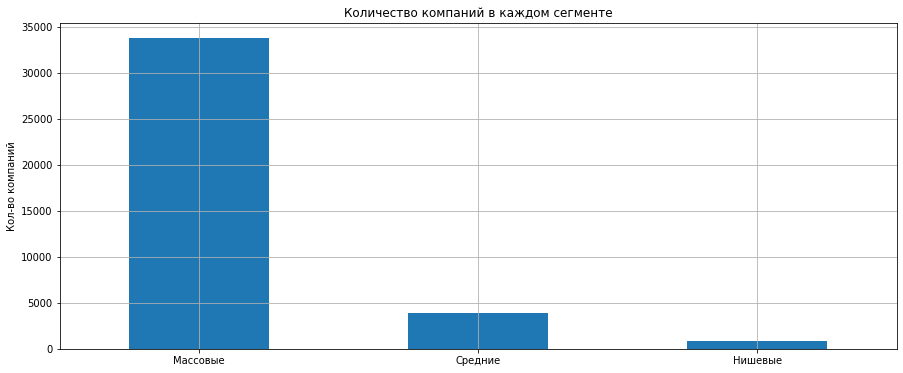

In [59]:
df_invest['market_category'].value_counts().plot(kind='bar',
                                                 title='Количество компаний в каждом сегменте',
                                                 ylabel='Кол-во компаний',
                                                 xlabel='',
                                                 rot=0,    
                                                 figsize=(15, 6))   

plt.grid()
plt.show()

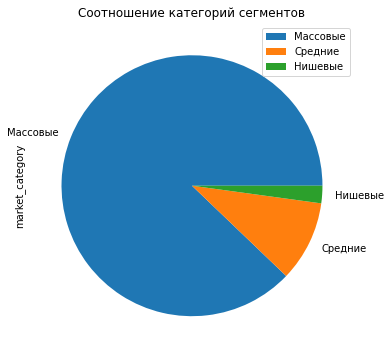

In [60]:
plt.figure(figsize=(12, 6))

df_invest['market_category'].value_counts(normalize=True).plot(kind='pie',
                                                               legend=True)
                                    
plt.title('Соотношение категорий сегментов')

plt.show()

Оставим в столбце `market` только массовые сегменты. Для остальных сегментов заменим значения на заглушки — `niche` для нишевых и `mid` для средних.

Дальнейшие исследования будем выполнять с учётом этой замены. Индивидуальные сегменты внутри средней и нишевой групп рассматривать не будем — они объединяются в два общих сегмента.


In [61]:
mid = df_invest[df_invest['market_category'] == 'Средние']

display(mid)

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,round_d,round_e,round_f,round_g,round_h,fund_interval,days,groups,market_counts,market_category
2,DuPont,http://www.dupont.com,_Business Services_Agriculture_Automotive_Inve...,businessservices,9.00000,operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0 days,0.0,Единичное финансирование,73.0,Средние
53,Bristol-Myers Squibb,http://www.bms.com,_Health and Wellness_Pharmaceuticals_Biotechno...,pharmaceuticals,15.51000,operating,USA,NY,New York City,New York,...,0.0,0.0,0.0,0.0,0.0,0 days,0.0,Единичное финансирование,76.0,Средние
58,General Electric,http://www.ge.com,_Media_Finance_Electronics_,media,2.00000,operating,USA,CT,Hartford,Fairfield,...,0.0,0.0,0.0,0.0,0.0,0 days,0.0,Единичное финансирование,101.0,Средние
72,Ziegler,http://www.ziegler.com/,_Financial Services_,financialservices,21.67500,operating,USA,IL,Chicago,Chicago,...,0.0,0.0,0.0,0.0,0.0,131 days,131.0,Срок финансирования до года,110.0,Средние
74,SodaStream,http://www.sodastream.com,_Consumer Electronics_Entertainment_Health and...,consumerelectronics,9.30000,operating,ISR,NaN,Tel Aviv,Lod,...,0.0,0.0,0.0,0.0,0.0,0 days,0.0,Единичное финансирование,76.0,Средние
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49358,Imagiscore,NaN,_Cloud-Based Music_Photo Sharing_Social Media_,photosharing,0.01000,operating,не_указано,NaN,NaN,не_указано,...,0.0,0.0,0.0,0.0,0.0,0 days,0.0,Единичное финансирование,45.0,Средние
49362,Blockstream,http://blockstream.com/,_Payments_Bitcoin_,payments,21.00000,operating,CAN,QC,Montreal,Montréal,...,0.0,0.0,0.0,0.0,0.0,0 days,0.0,Единичное финансирование,77.0,Средние
49378,AmbioPharm,http://ambiopharm.com,_Pharmaceuticals_,pharmaceuticals,23.99997,operating,USA,SC,SC - Other,North Augusta,...,0.0,0.0,0.0,0.0,0.0,0 days,0.0,Единичное финансирование,76.0,Средние
49384,Aequus Pharmaceuticals,http://aequuspharma.ca,_Pharmaceuticals_,pharmaceuticals,4.20000,operating,CAN,BC,Vancouver,Vancouver,...,0.0,0.0,0.0,0.0,0.0,0 days,0.0,Единичное финансирование,76.0,Средние


In [62]:
df_invest['market_category'] = df_invest['market_category'].replace('Средние', 'mid')

In [63]:
df_invest['market_category'] = df_invest['market_category'].replace('Нишевые', 'niche')

In [64]:
df_invest['market_category'] = df_invest['market_category'].replace('Массовые', 'mass')

In [65]:
df_invest['market_category']

0         mass
1          NaN
2          mid
3         mass
4         mass
         ...  
49433      NaN
49434    niche
49435      NaN
49436      NaN
49437     mass
Name: market_category, Length: 40907, dtype: category
Categories (3, object): ['niche' < 'mid' < 'mass']

In [66]:
categories_to_replace = ['niche', 'mid']

mask_to_update = df_invest['market_category'].isin(categories_to_replace)

df_invest.loc[mask_to_update, 'market'] = df_invest.loc[mask_to_update, 'market_category']

In [67]:
df_invest['market'].unique()

array(['education', nan, 'mid', 'socialmedia', 'hardware+software',
       'biotechnology', 'hospitality', 'enterprisesoftware',
       'manufacturing', 'finance', 'design', 'niche', 'nonprofits',
       'software', 'curatedweb', 'healthcare', 'healthandwellness',
       'cleantechnology', 'webhosting', 'e-commerce', 'automotive',
       'medical', 'fashion', 'security', 'networking', 'analytics',
       'semiconductors', 'publicrelations', 'travel', 'consulting',
       'realestate', 'technology', 'music', 'advertising', 'games',
       'mobile', 'internet', 'sports', 'photography', 'news', 'search',
       'messaging', 'video', 'marketplaces', 'entertainment', 'saas',
       'cloudcomputing', 'bigdata', 'apps', 'socialnetworkmedia',
       'startups'], dtype=object)

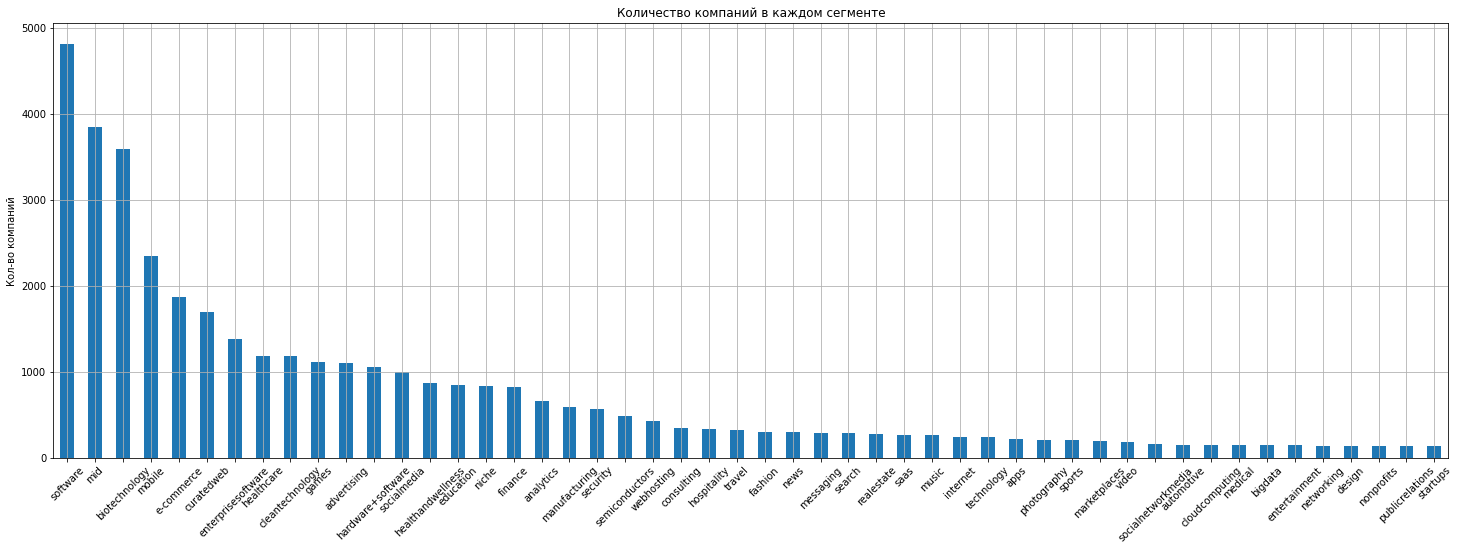

In [68]:
df_invest['market'].value_counts().plot(kind='bar',
                                        title='Количество компаний в каждом сегменте',
                                        ylabel='Кол-во компаний',
                                        xlabel='',
                                        rot=45,    
                                        figsize=(25, 8))   

plt.grid()
plt.show()

### 3.1. Анализируем и помечаем выбросы в каждом из сегментов

Так как аказчика интересует обычный для рассматриваемого периода размер средств, который предоставлялся компаниям, оценим, какой размер общего финансирования для одной компании будет типичным, а какой — выбивающимся. Укажим интервал, в котором лежат типичные значения.

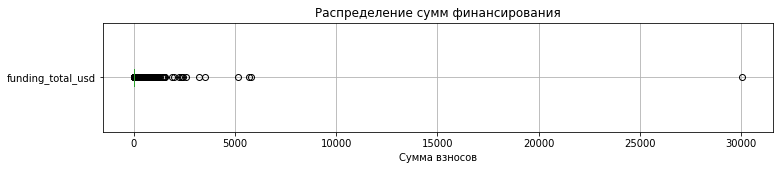

In [69]:
plt.figure(figsize=(12, 2))

df_invest.boxplot(column='funding_total_usd', vert=False)

plt.title('Распределение сумм финансирования')
plt.xlabel('Сумма взносов')
plt.show()

График нечитаемый, поэтому попорбуем вывести медиану и среднее значение, чтобы понять равномерность данных.

In [70]:
df_invest['funding_total_usd'].max() # также выясняем максимально значение выброса

30079.503

In [71]:
average_ftu = df_invest['funding_total_usd'].mean()
median_ftu = df_invest['funding_total_usd'].median()

display(average_ftu, median_ftu)

15.912526050407022

2.0

Отбросим аномальные значения и посмотрим "ящик с усами" поближе

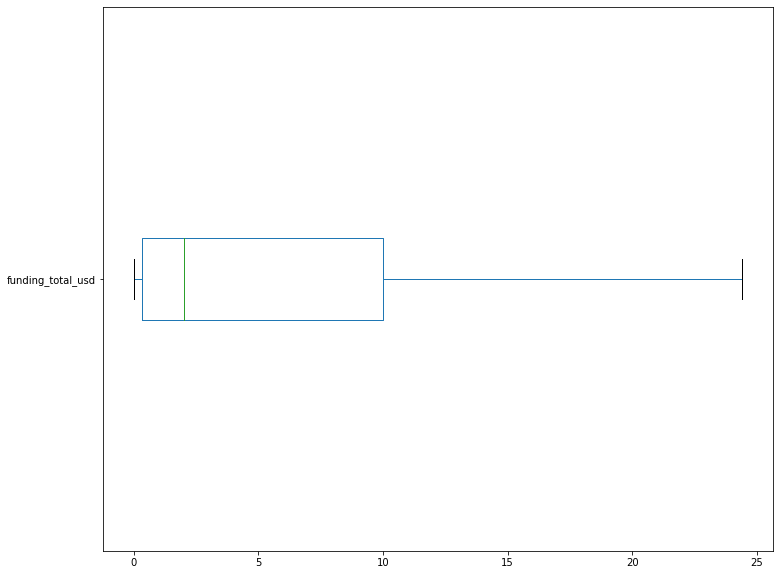

In [72]:
boxplot = df_invest.boxplot(column='funding_total_usd',
                  vert=False,
                  grid=False,
                  showfliers=False,
                  figsize=(12, 10))

plt.show()

Наиболее типичным размером финансирования являются взносы в 2 млн долларов. 

Определим компании с аномальным объёмом общего финансирования, используя метод IQR отдельно по каждому сегменту. 

Определим сегменты рынка с наибольшей долей компаний, получивших аномальное финансирование, и выведем топ таких сегментов.

In [73]:
# Инициализируем столбец outliers как False для всех строк
df_invest['outliers'] = False

# Для каждого рынка вычисляем выбросы и помечаем их
for market in df_invest['market'].unique():
    mask = df_invest['market'] == market
    data = df_invest.loc[mask, 'funding_total_usd']
    
    Q1, Q3 = data.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    # Помечаем выбросы в исходном датафрейме
    outlier_mask = (data < lower) | (data > upper)
    df_invest.loc[mask, 'outliers'] = outlier_mask

# Проверяем результат
print(df_invest[['market', 'funding_total_usd', 'outliers']].head())

      market  funding_total_usd  outliers
0  education              90.00      True
1        NaN               2.00     False
2        mid               9.00     False
3  education               7.70     False
4  education               0.54     False


In [74]:
df_invest['outliers'] = df_invest['outliers'].astype(int)

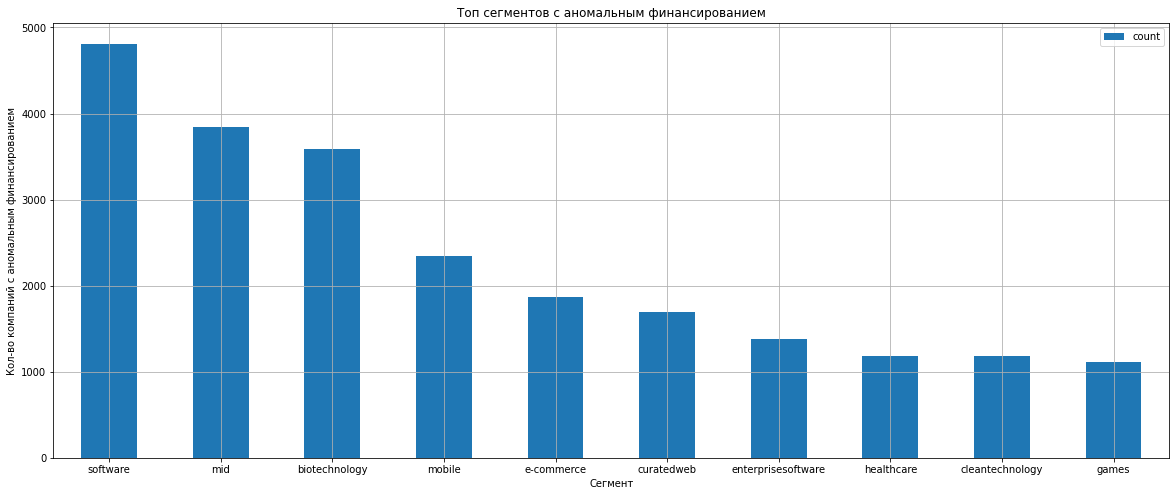

In [75]:
df_agg = df_invest.groupby('market')['outliers'].agg(['count']) 

df_agg = df_agg.sort_values(['count'], ascending=False)

top10 = df_agg.head(10)

top10.plot.bar(legend=True,
                title='Топ сегментов с аномальным финансированием', 
                ylabel='Кол-во компаний с аномальным финансированием',
                xlabel='Сегмент',
                rot=0,
                figsize=(20, 8))

plt.grid()
plt.show()

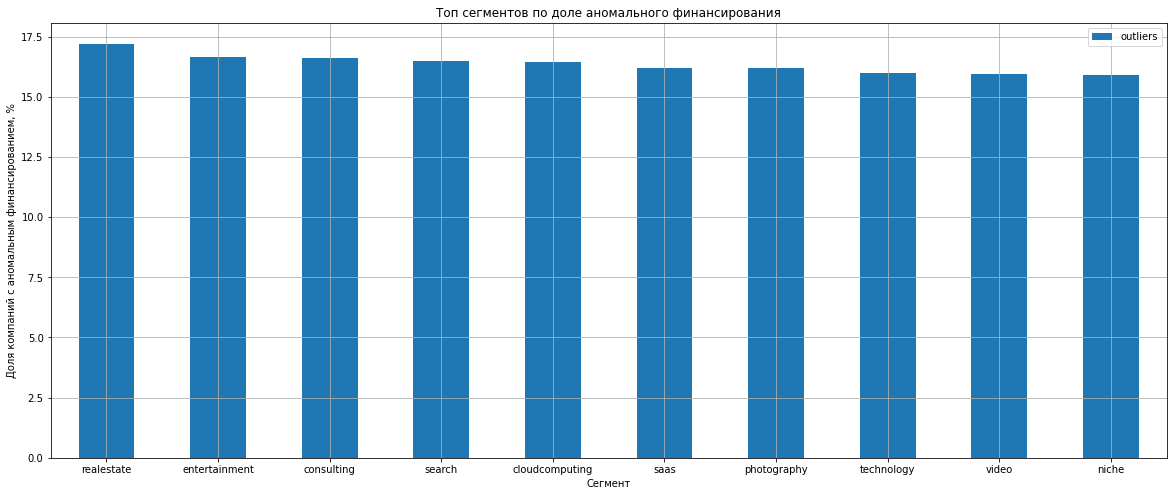

In [76]:
df_agg_part = df_invest.groupby('market')['outliers'].mean()

df_agg_part = df_agg_part * 100

df_agg_part = df_agg_part.sort_values(ascending=False)

df_agg_part10 = df_agg_part.head(10)

df_agg_part10.plot.bar(legend=True,
                title='Топ сегментов по доле аномального финансирования', 
                ylabel='Доля компаний с аномальным финансированием, %',
                xlabel='Сегмент',
                rot=0,
                figsize=(20, 8))

plt.grid()
plt.show()

### 3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии

Проверим по датасету, можно ли считать, что нам предоставили полные данные за 2014 год. Затем исключим из датасета компании, которые ранее посчитали получившими аномальное финансирование.

Когда исключим аномальные записи, оставим в датасете данные только об определённых компаниях. Они должны были получать финансирование в годы, когда было зафиксировано 50 или более раундов финансирования.

In [77]:
df_invest.head(10)

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,round_e,round_f,round_g,round_h,fund_interval,days,groups,market_counts,market_category,outliers
0,Harvard University,http://harvard.edu,_Education_,education,90.00,operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0 days,0.0,Единичное финансирование,844.0,mass,1
1,University of New Brunswick,http://www.unb.ca,не_указано,NaN,2.00,operating,не_указано,NaN,NaN,не_указано,...,0.0,0.0,0.0,0.0,0 days,0.0,Единичное финансирование,NaN,NaN,0
2,DuPont,http://www.dupont.com,_Business Services_Agriculture_Automotive_Inve...,mid,9.00,operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0 days,0.0,Единичное финансирование,73.0,mid,0
3,University of Michigan,http://www.umich.edu/,_Education_,education,7.70,operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,347 days,347.0,Срок финансирования до года,844.0,mass,0
4,Case Western Reserve University,http://www.case.edu,_Education_,education,0.54,operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0 days,0.0,Единичное финансирование,844.0,mass,0
5,Xavier University,http://www.xavier.edu/,не_указано,NaN,19.00,operating,USA,OH,Cincinnati,Cincinnati,...,0.0,0.0,0.0,0.0,0 days,0.0,Единичное финансирование,NaN,NaN,0
6,Tulane University,http://tulane.edu/,_Education_,education,12.00,operating,USA,LA,New Orleans,New Orleans,...,0.0,0.0,0.0,0.0,108 days,108.0,Срок финансирования до года,844.0,mass,1
7,Duke University,http://www.duke.edu,_Education_,education,8.70,operating,USA,NC,Raleigh,Durham,...,0.0,0.0,0.0,0.0,0 days,0.0,Единичное финансирование,844.0,mass,0
8,"Virginia Commonwealth University, Richmond",http://www.vcu.edu/,не_указано,NaN,6.00,operating,USA,VA,Richmond,Richmond,...,0.0,0.0,0.0,0.0,0 days,0.0,Единичное финансирование,NaN,NaN,0
9,WeGame,http://www.WeGame.com,_Social Media_,socialmedia,3.50,acquired,USA,CA,SF Bay Area,San Francisco,...,0.0,0.0,0.0,0.0,152 days,152.0,Срок финансирования до года,1003.0,mass,0


In [78]:
df_invest.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 40907 entries, 0 to 49437
Data columns (total 46 columns):
 #   Column                Non-Null Count  Dtype          
---  ------                --------------  -----          
 0   name                  40906 non-null  object         
 1   homepage_url          38593 non-null  object         
 2   category_list         40907 non-null  object         
 3   market                38404 non-null  object         
 4   funding_total_usd     40907 non-null  float64        
 5   status                40907 non-null  object         
 6   country_code          40907 non-null  object         
 7   state_code            25619 non-null  object         
 8   region                37088 non-null  object         
 9   city                  40907 non-null  object         
 10  funding_rounds        40907 non-null  float64        
 11  participants          27331 non-null  float64        
 12  founded_at            32201 non-null  object         
 13  f

Удаляем строку, где год 1636, тк он не входит в диапазон python

In [79]:
df_invest['founded_at'] = df_invest['founded_at'].drop(0)

In [80]:
df_invest['founded_at']

0               NaN
1        1785-01-01
2        1802-07-19
3        1817-01-01
4        1826-01-01
            ...    
49433           NaN
49434           NaN
49435           NaN
49436           NaN
49437           NaN
Name: founded_at, Length: 40907, dtype: object

In [81]:
df_invest['founded_at'] = pd.to_datetime(df_invest['founded_at'])

In [82]:
df_invest['founded_at']

0              NaT
1       1785-01-01
2       1802-07-19
3       1817-01-01
4       1826-01-01
           ...    
49433          NaT
49434          NaT
49435          NaT
49436          NaT
49437          NaT
Name: founded_at, Length: 40907, dtype: datetime64[ns]

In [83]:
df_invest['founded_month'] = pd.to_datetime(df_invest['founded_at']).dt.month

In [84]:
df_invest['founded_month']

0        NaN
1        1.0
2        7.0
3        1.0
4        1.0
        ... 
49433    NaN
49434    NaN
49435    NaN
49436    NaN
49437    NaN
Name: founded_month, Length: 40907, dtype: float64

In [85]:
companies_year = pd.pivot_table(df_invest,
                                index=['founded_year'],
                                values='name',
                                aggfunc=['count'])

display(companies_year.tail(50))

,count
,name
founded_year,
1965.0,2
1966.0,5
1967.0,10
1968.0,8
1969.0,15
1970.0,7
1971.0,10
1972.0,13


In [86]:
companies_year = pd.pivot_table(df_invest,
                                index=['founded_year', 'founded_month'],
                                values='name',
                                aggfunc=['count'])

display(companies_year.tail(50))

count
                            name
founded_year founded_month      
2010.0       11.0            136
             12.0            118
2011.0       1.0            1976
             2.0             175
             3.0             199
             4.0             185
             5.0             202
             6.0             216
             7.0             172
             8.0             180
             9.0             197
             10.0            180
             11.0            218
             12.0            144
2012.0       1.0            1946
             2.0             229
             3.0             231
             4.0             224
             5.0             212
             6.0             243
             7.0             207
             8.0             200
             9.0             215
             10.0            188
             11.0            179
             12.0            160
2013.0       1.0            1394
             2.0             178
             3.0             198
             4.0             186
             5.0             190
             6.0             189
             7.0             172
             8.0             134
             9.0             141
             10.0            153
             11.0            131
             12.0             97
2014.0       1.0             414
             2.0             110
             3.0             115
             4.0              98
             5.0              81
             6.0              73
             7.0              46
             8.0              31
             9.0              26
             10.0             16
             11.0              3
             12.0              2

Согласно данным, в 2014 году был самый минимальный прирост компаний за последние 10 лет. Более того, за последние несколько лет, в ноябре и декабре прирост компаний был около 100 шт., а в 2014 в оба месяца всего 3 шт. и 2 шт. На протяжение всего года заметен недобор по приросту компаний. Возможно, на момент создания датасета, не все компании были зарегестрированы и загружены.

In [87]:
df_invest['first_funding_at']

0       2014-01-06
1       2014-05-15
2       2009-07-02
3       2013-11-21
4       2014-01-14
           ...    
49433   2014-12-01
49434   2014-12-01
49435   2014-12-02
49436   2014-12-02
49437   2014-12-31
Name: first_funding_at, Length: 40907, dtype: datetime64[ns]

In [88]:
df_invest['first_funding_at_year'] = pd.to_datetime(df_invest['first_funding_at']).dt.year

In [89]:
df_invest['first_funding_at_month'] = pd.to_datetime(df_invest['first_funding_at']).dt.month

In [90]:
df_invest['mid_funding_at_year'] = pd.to_datetime(df_invest['mid_funding_at']).dt.year

In [91]:
df_invest['mid_funding_at_month'] = pd.to_datetime(df_invest['mid_funding_at']).dt.month

In [92]:
df_invest['last_funding_at_year'] = pd.to_datetime(df_invest['last_funding_at']).dt.year

In [93]:
df_invest['last_funding_at_month'] = pd.to_datetime(df_invest['last_funding_at']).dt.month

In [94]:
df_invest['last_funding_at_month']

0         1
1         5
2         7
3        11
4         1
         ..
49433    12
49434    12
49435    12
49436    12
49437    12
Name: last_funding_at_month, Length: 40907, dtype: int64

In [95]:
companies_fund_year = pd.pivot_table(df_invest,
                                     index=['first_funding_at_year', 'first_funding_at_month'],
                                     values='name',
                                     aggfunc=['count'])

display(companies_fund_year.tail(50))

count
                                              name
first_funding_at_year first_funding_at_month      
2010.0                11.0                     311
                      12.0                     347
2011.0                1.0                      591
                      2.0                      342
                      3.0                      387
                      4.0                      389
                      5.0                      358
                      6.0                      432
                      7.0                      384
                      8.0                      437
                      9.0                      413
                      10.0                     404
                      11.0                     409
                      12.0                     418
2012.0                1.0                      713
                      2.0                      362
                      3.0                      496
                      4.0                      460
                      5.0                      445
                      6.0                      469
                      7.0                      464
                      8.0                      509
                      9.0                      462
                      10.0                     485
                      11.0                     485
                      12.0                     397
2013.0                1.0                      696
                      2.0                      446
                      3.0                      536
                      4.0                      505
                      5.0                      505
                      6.0                      591
                      7.0                      596
                      8.0                      640
                      9.0                      726
                      10.0                     657
                      11.0                     630
                      12.0                     648
2014.0                1.0                      810
                      2.0                      635
                      3.0                      661
                      4.0                      593
                      5.0                      549
                      6.0                      669
                      7.0                      671
                      8.0                      525
                      9.0                      538
                      10.0                     492
                      11.0                     311
                      12.0                      23

In [96]:
companies_fund_year = pd.pivot_table(df_invest,
                                     index=['mid_funding_at_year', 'mid_funding_at_month'],
                                     values='name',
                                     aggfunc=['count'])

display(companies_fund_year.tail(50))

count
                                          name
mid_funding_at_year mid_funding_at_month      
2010.0              11.0                   292
                    12.0                   307
2011.0              1.0                    522
                    2.0                    324
                    3.0                    364
                    4.0                    358
                    5.0                    375
                    6.0                    426
                    7.0                    396
                    8.0                    431
                    9.0                    414
                    10.0                   393
                    11.0                   438
                    12.0                   422
2012.0              1.0                    645
                    2.0                    381
                    3.0                    514
                    4.0                    487
                    5.0                    474
                    6.0                    478
                    7.0                    538
                    8.0                    538
                    9.0                    510
                    10.0                   547
                    11.0                   515
                    12.0                   461
2013.0              1.0                    730
                    2.0                    520
                    3.0                    653
                    4.0                    642
                    5.0                    633
                    6.0                    734
                    7.0                    754
                    8.0                    775
                    9.0                    780
                    10.0                   783
                    11.0                   762
                    12.0                   657
2014.0              1.0                    739
                    2.0                    600
                    3.0                    676
                    4.0                    645
                    5.0                    600
                    6.0                    740
                    7.0                    687
                    8.0                    559
                    9.0                    547
                    10.0                   497
                    11.0                   306
                    12.0                    23

In [97]:
companies_fund_year = pd.pivot_table(df_invest,
                                     index=['last_funding_at_year', 'last_funding_at_month'],
                                     values='name',
                                     aggfunc=['count'])

display(companies_fund_year.tail(50))

count
                                            name
last_funding_at_year last_funding_at_month      
2010                 11                      258
                     12                      292
2011                 1                       474
                     2                       308
                     3                       311
                     4                       290
                     5                       303
                     6                       379
                     7                       328
                     8                       363
                     9                       346
                     10                      329
                     11                      337
                     12                      341
2012                 1                       572
                     2                       332
                     3                       444
                     4                       450
                     5                       411
                     6                       423
                     7                       483
                     8                       462
                     9                       416
                     10                      468
                     11                      451
                     12                      383
2013                 1                       653
                     2                       472
                     3                       578
                     4                       564
                     5                       611
                     6                       747
                     7                       727
                     8                       766
                     9                       936
                     10                      899
                     11                      818
                     12                      916
2014                 1                      1178
                     2                       947
                     3                      1072
                     4                      1077
                     5                      1036
                     6                      1229
                     7                      1254
                     8                      1064
                     9                      1135
                     10                     1139
                     11                      732
                     12                       52

В целом, по финансированию данные относительно равномерно распределены, 2014 году даже заметен прирост. Однако показатели декабря 2014 года на всех этапах: начальный, средний и последний, сильно малы, что может наводить на мысль, что данные могут быть неполными.

Оставляем в датасете данные только об определённых компаниях. Они должны были получать финансирование в годы, когда было зафиксировано 50 или более раундов финансирования:

In [98]:
df_invest = df_invest[df_invest['outliers'] == 0]

In [99]:
df_invest['outliers']

1        0
2        0
3        0
4        0
5        0
        ..
49433    0
49434    0
49435    0
49436    0
49437    0
Name: outliers, Length: 36036, dtype: int64

In [100]:
companies_mid_year = pd.pivot_table(df_invest,
                                    index=['mid_funding_at_year'],
                                    values='funding_rounds',
                                    aggfunc=['sum'])

display(companies_mid_year)

,sum
,funding_rounds
mid_funding_at_year,
1921.0,1.0
1960.0,2.0
1979.0,1.0
1982.0,3.0
1983.0,1.0
1984.0,2.0
1985.0,3.0
1987.0,2.0


In [101]:
df_invest = df_invest[df_invest['mid_funding_at_year'] > 1999]

In [102]:
companies_mid_year = pd.pivot_table(df_invest,
                                    index=['mid_funding_at_year'],
                                    values='funding_rounds',
                                    aggfunc=['sum'])

display(companies_mid_year)

,sum
,funding_rounds
mid_funding_at_year,
2000.0,122.0
2001.0,84.0
2002.0,107.0
2003.0,128.0
2004.0,189.0
2005.0,958.0
2006.0,1881.0
2007.0,2849.0


Таким образом, оставили в датасете компании с финансированием c 2000 по 2014 гг.

### 3.3. Анализ типов финансирования по объёму и популярности

Построим график, который покажет, какие типы финансирования в сумме привлекли больше всего денег. Будем ориентироваться на значения в столбцах `seed`, `venture`, `equity_crowdfunding`, `undisclosed`, `convertible_note`, `debt_financing`, `angel`, `grant`, `private_equity`, `post_ipo_equity`, `post_ipo_debt`, `secondary_market` и `product_crowdfunding`.

Также построим график, который покажет популярность разных типов финансирования — какие типы финансирования чаще всего используются компаниями, то есть встречаются в датасете наибольшее количество раз.

Сравним графики и выделим часто используемые типы финансирования, которые при этом характеризуются небольшими объёмами, и наоборот — те, что встречаются редко, но при этом характеризуются значительным объёмом предоставленных сумм.

In [103]:
df_return

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,16.70,55.40,0.00,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.00,0.20,0.00
2001,2.88,23.49,0.00,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.00,0.46,0.00
2002,6.59,209.42,0.00,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.00,0.06,0.00
2003,7.74,233.86,0.00,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.00,0.08,0.00
2004,9.93,555.90,0.00,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.00,0.55,0.00
2005,26.60,2628.92,0.00,9.51,0.02,35.09,31.06,0.0,2.40,3.51,0.00,0.05,0.00
2006,61.81,3100.18,0.19,46.74,1.78,113.21,47.75,0.0,16.67,20.58,0.00,0.12,0.00
2007,70.41,3585.37,0.01,55.37,3.22,125.68,164.51,0.0,88.81,24.36,0.00,0.57,0.00
2008,89.72,2717.02,0.03,41.02,1.71,397.54,102.83,0.0,130.38,84.28,0.00,0.47,0.00


In [104]:
column_sums = df_return.sum().sort_values(ascending=False)

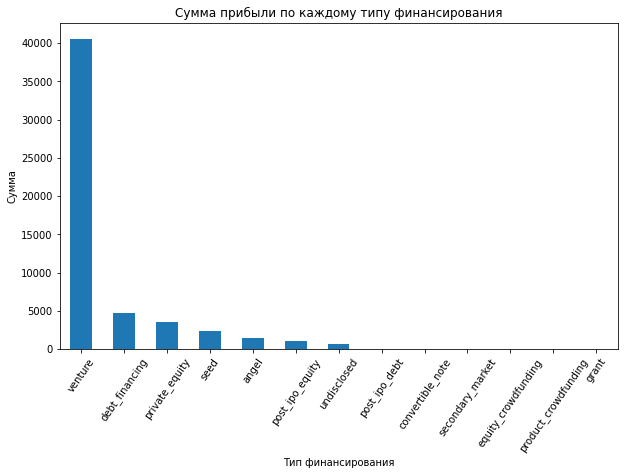

In [105]:
plt.figure(figsize=(10, 6))



column_sums.plot(kind='bar',
                 rot=55)

plt.title('Сумма прибыли по каждому типу финансирования')
plt.xlabel('Тип финансирования')
plt.ylabel('Сумма')

plt.show()

In [106]:
columns_to_replace = ['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding']

In [107]:
df_invest[columns_to_replace] = df_invest[columns_to_replace].astype(int)

In [109]:
df_invest[columns_to_replace] = df_invest[columns_to_replace].replace(0, np.nan)

In [110]:
df_invest[columns_to_replace]

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
1,NaN,2000000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,9000000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,1600000.0,NaN,NaN,NaN,6100000.0,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,540000.0,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19000000.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49433,NaN,1500000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49434,NaN,9000000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49435,NaN,250000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49436,NaN,34000000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [111]:
print(f"Количество пропусков: {df_invest['seed'].isnull().sum()}")

Количество пропусков: 22571


In [112]:
columns_to_count = ['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding']

In [113]:
counts = df_invest[columns_to_count].count().sort_values(ascending=False)

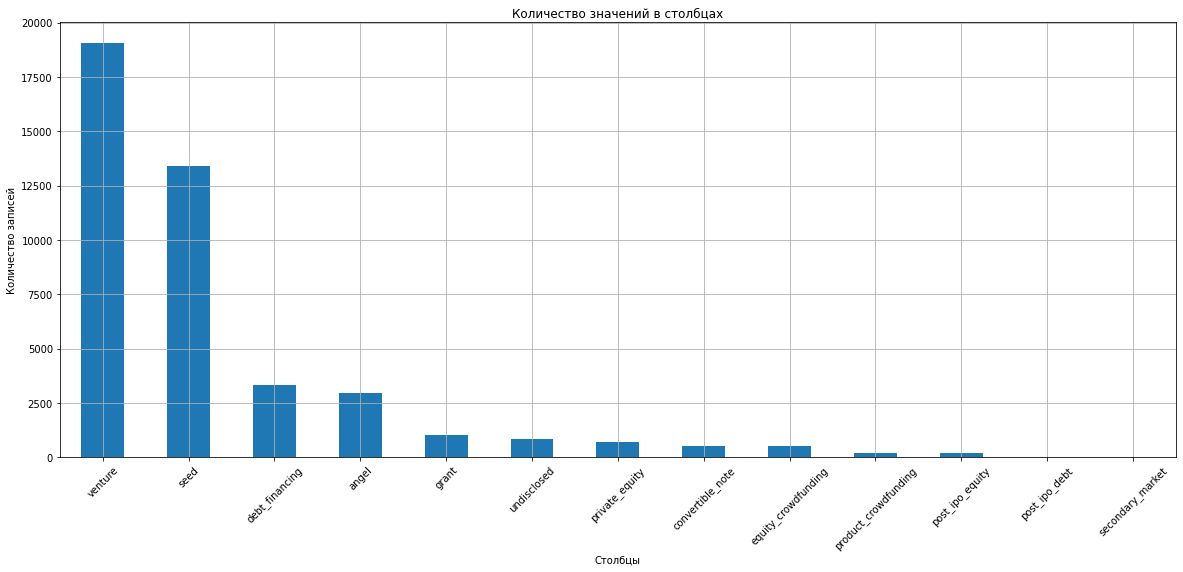

In [114]:
plt.figure(figsize=(20, 8))

counts.plot(kind='bar',
            rot=45)

plt.title('Количество значений в столбцах')
plt.xlabel('Столбцы')
plt.ylabel('Количество записей')

plt.grid()
plt.show()

Построим график суммарных объёмов возвратов от разных типов финансирования за весь период на основе дополнительного датасета.

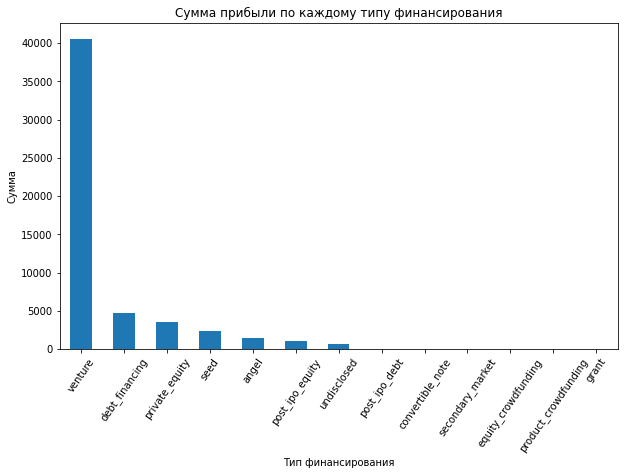

In [115]:
plt.figure(figsize=(10, 6))



column_sums.plot(kind='bar',
                 rot=55)

plt.title('Сумма прибыли по каждому типу финансирования')
plt.xlabel('Тип финансирования')
plt.ylabel('Сумма')

plt.show()

На двух графиках видно, что лидером с серьезным отрывом по популярности и сумме возвратов инвестиций являются венчурные инвестиции ('venture'). Посевные инвестиции ('seed') хоть и пользуются популярностью, но сумма возвратов от них невысокая. Сумма возвратов по грантам ('grant') вообще равна нулю, хотя, как вид винансирования, они занимают 5-е место из 13-ти. Однако, инвестиции в виде прямых (частных) вложений ('private_equity') и тип финансирования после IPO ('post_ipo_equity'), наоборот, показали достойные показатели по сумме возвратов: 3-е и 6-е места, хотя не самые популярные вид финансирования: 7-е и 11-е места.  

## Анализ динамики

### 4.1 Динамика предоставления финансирования по годам

Используя столбцы `funding_total_usd` и `funding_rounds`, рассчитаем для каждой компании средний объём одного раунда финансирования.

На основе получившейся таблицы построим графики, отражающие:
* динамику типичного размера средств, которые стартапы получали в рамках одного раунда финансирования;

* динамику общего количества раундов за каждый год, то есть насколько активно происходили инвестиции на рынке (чем больше раундов, тем выше активность).

Будем строить графики, используя данные только по тем компаниям, которые остались в датасете после предыдущих фильтраций.

На основе полученных данных ответим на вопросы:
* В каком году типичный размер средств, собранных в рамках одного раунда, был максимальным?

* Какая тенденция наблюдалась в 2014 году по количеству раундов и средств, выделяемых в рамках каждого раунда?

In [116]:
df_invest[['name', 'funding_total_usd', 'funding_rounds']].head(5)

,name,funding_total_usd,funding_rounds
1,University of New Brunswick,2.00,1.0
2,DuPont,9.00,1.0
3,University of Michigan,7.70,3.0
4,Case Western Reserve University,0.54,1.0
5,Xavier University,19.00,1.0


In [117]:
df_invest['avg_funding'] = df_invest['funding_total_usd'] / df_invest['funding_rounds']

In [118]:
df_invest[['name', 'funding_total_usd', 'funding_rounds', 'avg_funding']].head(5)

,name,funding_total_usd,funding_rounds,avg_funding
1,University of New Brunswick,2.00,1.0,2.000000
2,DuPont,9.00,1.0,9.000000
3,University of Michigan,7.70,3.0,2.566667
4,Case Western Reserve University,0.54,1.0,0.540000
5,Xavier University,19.00,1.0,19.000000


In [119]:
df_invest['avg_funding'] = df_invest['avg_funding'].astype(int)

In [120]:
df_invest[['name', 'funding_total_usd', 'funding_rounds', 'avg_funding']].head(5)

,name,funding_total_usd,funding_rounds,avg_funding
1,University of New Brunswick,2.00,1.0,2
2,DuPont,9.00,1.0,9
3,University of Michigan,7.70,3.0,2
4,Case Western Reserve University,0.54,1.0,0
5,Xavier University,19.00,1.0,19


In [121]:
df_invest = df_invest.sort_values('avg_funding', ascending=False)

In [122]:
df_invest[['avg_funding', 'founded_year']].head(15)

,avg_funding,founded_year
47589,3200,NaN
1432,2581,1993.0
47615,804,NaN
381,750,1976.0
43832,674,NaN
17681,500,2009.0
40049,449,NaN
29545,415,2012.0
126,373,1930.0
19588,367,2010.0


In [123]:
df_invest['avg_funding'].mean()

2.9974137211824576

In [124]:
df_invest['avg_funding'].median()

1.0

Типичный размер средств, собранных в рамках одного раунда, был максимальным в 1993 году и составил 2 581 256 715 долларов.

In [125]:
df_invest = df_invest[df_invest['founded_year'] > 1999]

In [126]:
df_invest = df_invest.sort_values('founded_year', ascending=False)

In [127]:
avg_fund_ayear = pd.pivot_table(df_invest,
                                index= ['founded_year'],
                                values='avg_funding',
                                aggfunc=['mean', 'median'])

display(avg_fund_ayear.tail(50))

,mean,median
,avg_funding,avg_funding
founded_year,,
2000.0,6.429285,4
2001.0,5.598020,4
2002.0,5.689214,3
2003.0,5.227964,3
2004.0,4.493280,3
2005.0,3.599583,2
2006.0,3.313916,1
2007.0,2.739799,1


In [128]:
avg_fund_ayear = pd.pivot_table(df_invest,
                                index= ['founded_year', 'funding_rounds'],
                                values='avg_funding',
                                aggfunc=['mean', 'median'])

display(avg_fund_ayear.tail(50))

mean      median
                            avg_funding avg_funding
founded_year funding_rounds                        
2009.0       4.0               1.791209         1.0
             5.0               2.052632         1.0
             6.0               2.285714         1.0
             7.0               1.111111         1.0
             8.0               0.000000         0.0
             9.0               1.000000         0.5
             10.0              1.000000         1.0
             11.0              1.000000         1.0
2010.0       1.0               1.987995         0.0
             2.0               1.499253         0.0
             3.0               1.620000         1.0
             4.0               1.503817         1.0
             5.0               1.475000         0.0
             6.0               0.695652         0.0
             7.0               0.666667         0.0
             8.0               1.666667         1.0
             9.0               0.000000         0.0
             10.0              0.000000         0.0
2011.0       1.0               1.221239         0.0
             2.0               1.426426         0.0
             3.0               1.306905         0.0
             4.0               1.339744         0.0
             5.0               1.085106         0.0
             6.0               0.366667         0.0
             7.0               0.857143         1.0
             8.0               0.250000         0.0
             9.0               0.000000         0.0
2012.0       1.0               1.188198         0.0
             2.0               1.088093         0.0
             3.0               1.089855         0.0
             4.0               0.600000         0.0
             5.0               0.523810         0.0
             6.0               0.176471         0.0
             7.0               0.000000         0.0
             8.0               0.000000         0.0
             9.0               0.000000         0.0
             12.0              0.000000         0.0
2013.0       1.0               0.891929         0.0
             2.0               0.804314         0.0
             3.0               0.700000         0.0
             4.0               0.365854         0.0
             5.0               0.666667         0.0
             6.0               0.000000         0.0
             7.0               0.000000         0.0
2014.0       1.0               0.947867         0.0
             2.0               0.333333         0.0
             3.0               0.047619         0.0
             4.0               0.000000         0.0
             5.0               0.000000         0.0
             10.0              0.000000         0.0

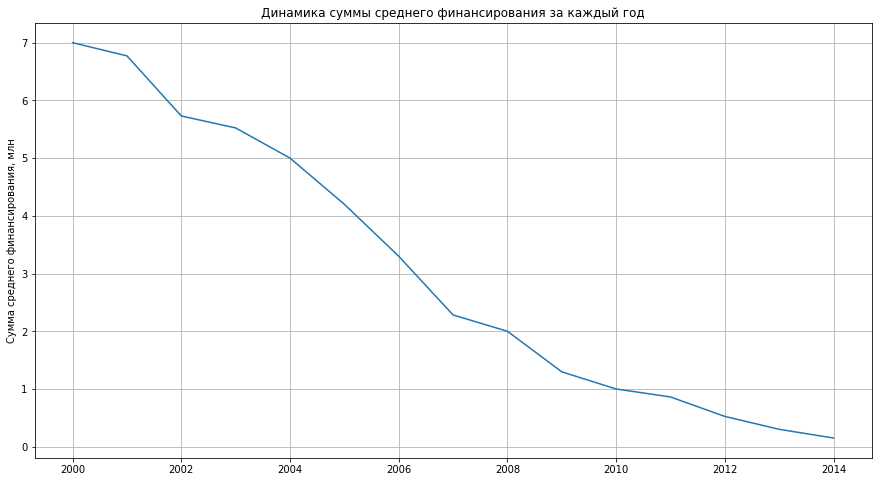

In [129]:
mean_funding_year = df_invest.groupby('founded_year')['funding_total_usd'].median()


mean_funding_year.plot(kind='line',
                       figsize=(15, 8))
                 
plt.title('Динамика суммы среднего финансирования за каждый год')
plt.xlabel('')
plt.ylabel('Сумма среднего финансирования, млн')

plt.grid()
plt.show()

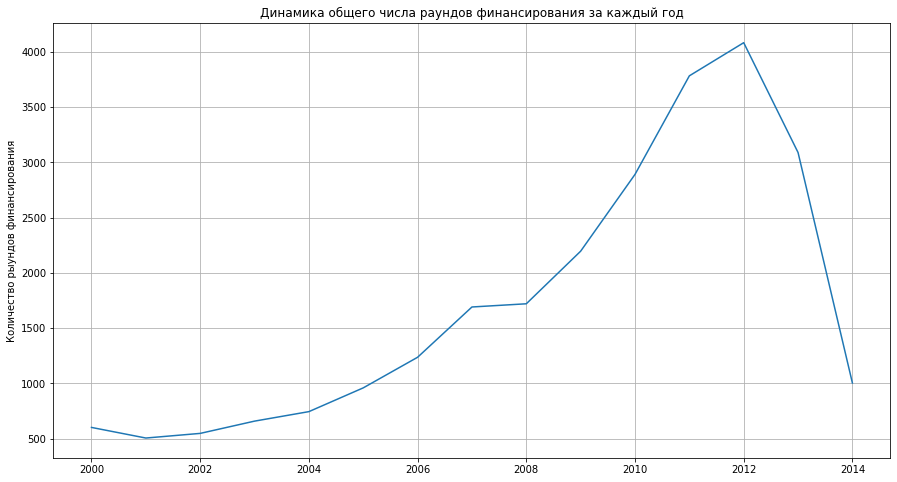

In [130]:
count_funding_rounds_year = df_invest.groupby('founded_year')['funding_rounds'].count()


count_funding_rounds_year.plot(kind='line',
                             figsize=(15, 8))
                 
plt.title('Динамика общего числа раундов финансирования за каждый год')
plt.xlabel('')
plt.ylabel('Количество рыундов финансирования')

plt.grid()
plt.show()

- Какая тенденция наблюдалась в 2014 году по количеству раундов и средств, выделяемых в рамках каждого раунда?

С 2000-ого года количество выделяемого финансирования с каждым годом становилось все меньше и к 2014 году достигло своего минимума за все время. Также, количество раундов финансирования c 2012-ого года резко пошло на спад и в 2014 году достигло уровня 2005 года, 1000 финансирований в год, хотя ранее было в разы больше.

### 4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

Составим сводную таблицу, в которой укажем суммарный размер общего финансирования `funding_total_usd` по годам и сегментам рынка. Отберем из неё только те сегменты, которые показывали рост размера суммарного финансирования в 2014 году по сравнению с 2013.

На графике отразим, как менялся суммарный размер общего финансирования в каждом из отобранных сегментов по годам, за которые у нас достаточно данных. Рассмотрим только массовые сегменты, а средние и нишевые исключим.

In [131]:
pivot_table = pd.pivot_table(df_invest,
                             index='founded_year',
                             columns='market', 
                             values='funding_total_usd',
                             aggfunc='sum')

funding_2013 = pivot_table.loc[2013]
funding_2014 = pivot_table.loc[2014]

growth_markets = funding_2014[funding_2014 > funding_2013].index

result_table = pivot_table[growth_markets]

display(result_table)

market,apps,manufacturing,medical,publicrelations,webhosting
founded_year,,,,,
2000.0,NaN,74.026245,NaN,37.695354,642.082141
2001.0,NaN,82.714163,27.303920,11.000000,110.329059
2002.0,NaN,45.343450,10.002500,7.600000,243.588656
2003.0,NaN,140.457861,NaN,13.990000,201.601542
2004.0,NaN,168.518579,2.500000,10.287768,262.151311
2005.0,2.180600,113.024917,6.350000,7.726064,224.536309
2006.0,NaN,126.033612,1.495092,7.324000,104.347796
2007.0,5.333319,145.646099,14.140921,25.492594,170.799039
2008.0,10.408651,133.712359,19.632000,0.485000,105.256450


In [132]:
result_table = result_table[result_table.index > 2006]

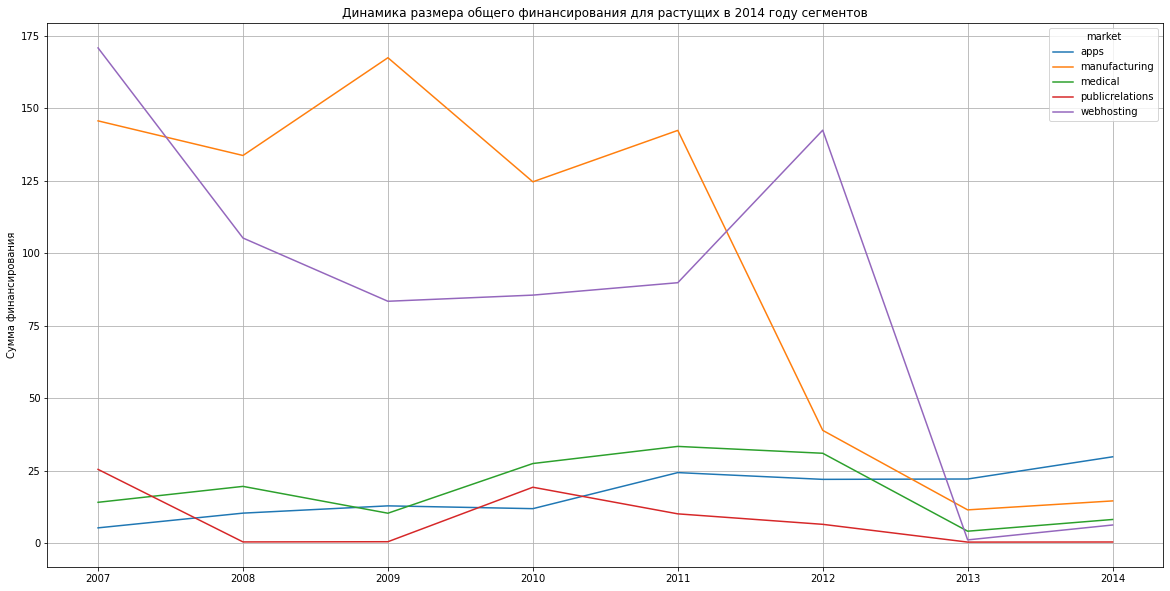

In [133]:
result_table.plot(kind='line',
                  figsize=(20, 10))
                 
plt.title('Динамика размера общего финансирования для растущих в 2014 году сегментов')
plt.xlabel('')
plt.ylabel('Сумма финансирования')

plt.grid()
plt.show()

Исходя из графика, можно сказать, что наиболее стабильный рост показывает сегмент 'apps', но его нельзя назвать быстрым.  

### 4.3 Годовая динамика доли возвращённых средств по типам финансирования

Нам необходимо узнать, какая часть вложенных или выданных денег со временем возвращается обратно инвесторам или финансистам. Поэтому для каждого года и каждого вида финансирования рассчитаем нормированные значения возврата средств: то есть какую долю возвращённые средства составляют от предоставленных.

In [134]:
df_invest.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 25706 entries, 37649 to 4321
Data columns (total 53 columns):
 #   Column                  Non-Null Count  Dtype          
---  ------                  --------------  -----          
 0   name                    25705 non-null  object         
 1   homepage_url            24639 non-null  object         
 2   category_list           25706 non-null  object         
 3   market                  24693 non-null  object         
 4   funding_total_usd       25706 non-null  float64        
 5   status                  25706 non-null  object         
 6   country_code            25706 non-null  object         
 7   state_code              16053 non-null  object         
 8   region                  23577 non-null  object         
 9   city                    25706 non-null  object         
 10  funding_rounds          25706 non-null  float64        
 11  participants            17295 non-null  float64        
 12  founded_at              25706

In [135]:
df_invest['first_funding_at_year'].unique()

array([2014., 2013., 2011., 2008., 2012., 2010., 2009., 2006., 2007.,
       2004., 2005., 2002., 2003., 1999., 2000., 2001.])

In [136]:
df_invest = df_invest[df_invest['first_funding_at_year'] > 1999]

In [137]:
df_invest['first_funding_at_year'].unique()

array([2014., 2013., 2011., 2008., 2012., 2010., 2009., 2006., 2007.,
       2004., 2005., 2002., 2003., 2000., 2001.])

In [138]:
df_invest = df_invest[['first_funding_at_year', 'venture', 'debt_financing', 'private_equity', 'seed', 'angel']]

In [139]:
df_invest['first_funding_at_year'] = df_invest['first_funding_at_year'].astype(int)

In [140]:
df_invest = df_invest.sort_values('first_funding_at_year', ascending=True)

In [141]:
df_invest = df_invest.groupby('first_funding_at_year').sum().reset_index()

In [142]:
df_invest = df_invest.set_index('first_funding_at_year')

In [143]:
df_invest

,venture,debt_financing,private_equity,seed,angel
first_funding_at_year,,,,,
2000,1.204032e+08,1.000000e+07,0.000000e+00,8.597440e+06,8303972.0
2001,2.187080e+08,1.157922e+07,0.000000e+00,8.877235e+06,650000.0
2002,3.409015e+08,2.050000e+06,0.000000e+00,1.029019e+07,2900000.0
2003,5.499987e+08,1.731994e+06,0.000000e+00,2.118336e+07,5829661.0
2004,1.005574e+09,4.839674e+07,4.950000e+05,1.870073e+07,15880741.0
2005,6.431649e+09,1.131948e+08,1.045536e+07,4.642966e+07,55514621.0
2006,7.057689e+09,1.393461e+08,4.868660e+07,8.524810e+07,74857066.0
2007,7.261964e+09,2.519215e+08,7.590230e+07,1.826263e+08,180156129.0
2008,7.044899e+09,2.747619e+08,1.399601e+08,2.606599e+08,228261087.0


In [144]:
df_return

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,16.70,55.40,0.00,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.00,0.20,0.00
2001,2.88,23.49,0.00,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.00,0.46,0.00
2002,6.59,209.42,0.00,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.00,0.06,0.00
2003,7.74,233.86,0.00,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.00,0.08,0.00
2004,9.93,555.90,0.00,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.00,0.55,0.00
2005,26.60,2628.92,0.00,9.51,0.02,35.09,31.06,0.0,2.40,3.51,0.00,0.05,0.00
2006,61.81,3100.18,0.19,46.74,1.78,113.21,47.75,0.0,16.67,20.58,0.00,0.12,0.00
2007,70.41,3585.37,0.01,55.37,3.22,125.68,164.51,0.0,88.81,24.36,0.00,0.57,0.00
2008,89.72,2717.02,0.03,41.02,1.71,397.54,102.83,0.0,130.38,84.28,0.00,0.47,0.00


In [145]:
df_return = df_return[['venture', 'debt_financing', 'private_equity', 'seed', 'angel']]

In [146]:
df_return

,venture,debt_financing,private_equity,seed,angel
year,,,,,
2000,55.40,8.66,0.00,16.70,6.43
2001,23.49,4.49,0.00,2.88,1.18
2002,209.42,3.42,1.51,6.59,3.41
2003,233.86,1.09,1.62,7.74,3.41
2004,555.90,13.55,2.19,9.93,9.18
2005,2628.92,35.09,2.40,26.60,31.06
2006,3100.18,113.21,16.67,61.81,47.75
2007,3585.37,125.68,88.81,70.41,164.51
2008,2717.02,397.54,130.38,89.72,102.83


In [147]:
return_ratio = df_return / (df_invest + 1e-60)

In [148]:
display(return_ratio)

,venture,debt_financing,private_equity,seed,angel
year,,,,,
2000,4.601208e-07,8.660000e-07,0.000000e+00,1.942439e-06,7.743282e-07
2001,1.074035e-07,3.877637e-07,0.000000e+00,3.244253e-07,1.815385e-06
2002,6.143123e-07,1.668293e-06,1.510000e+60,6.404157e-07,1.175862e-06
2003,4.252010e-07,6.293324e-07,1.620000e+60,3.653812e-07,5.849397e-07
2004,5.528186e-07,2.799776e-07,4.424242e-06,5.309954e-07,5.780587e-07
2005,4.087474e-07,3.099966e-07,2.295473e-07,5.729096e-07,5.594922e-07
2006,4.392628e-07,8.124375e-07,3.423940e-07,7.250601e-07,6.378823e-07
2007,4.937190e-07,4.988856e-07,1.170057e-06,3.855413e-07,9.131524e-07
2008,3.856720e-07,1.446853e-06,9.315515e-07,3.442033e-07,4.504929e-07


Построим график, на котором отобразим нормированные значения возврата средств для типов финансирования `venture`, `debt_financing`, `private_equity`, `seed` и `angel`.

In [149]:
return_ratio = return_ratio[['venture', 'debt_financing', 'private_equity', 'seed', 'angel']]

In [150]:
return_ratio

,venture,debt_financing,private_equity,seed,angel
year,,,,,
2000,4.601208e-07,8.660000e-07,0.000000e+00,1.942439e-06,7.743282e-07
2001,1.074035e-07,3.877637e-07,0.000000e+00,3.244253e-07,1.815385e-06
2002,6.143123e-07,1.668293e-06,1.510000e+60,6.404157e-07,1.175862e-06
2003,4.252010e-07,6.293324e-07,1.620000e+60,3.653812e-07,5.849397e-07
2004,5.528186e-07,2.799776e-07,4.424242e-06,5.309954e-07,5.780587e-07
2005,4.087474e-07,3.099966e-07,2.295473e-07,5.729096e-07,5.594922e-07
2006,4.392628e-07,8.124375e-07,3.423940e-07,7.250601e-07,6.378823e-07
2007,4.937190e-07,4.988856e-07,1.170057e-06,3.855413e-07,9.131524e-07
2008,3.856720e-07,1.446853e-06,9.315515e-07,3.442033e-07,4.504929e-07


In [151]:
return_ratio.loc[2001, 'angel'] = None

In [152]:
return_ratio.loc[2002, 'private_equity'] = None

In [153]:
return_ratio.loc[2003, 'private_equity'] = None

In [154]:
return_ratio.loc[2004, 'private_equity'] = None

In [158]:
return_ratio[['venture', 'debt_financing', 'private_equity', 'seed', 'angel']] = return_ratio[['venture', 'debt_financing', 'private_equity', 'seed', 'angel']] / 1000000

In [161]:
return_ratio

,venture,debt_financing,private_equity,seed,angel
year,,,,,
2000,4.601208e-19,8.660000e-13,0.000000e+00,1.942439e-12,7.743282e-13
2001,1.074035e-19,3.877637e-13,0.000000e+00,3.244253e-13,NaN
2002,6.143123e-19,1.668293e-12,NaN,6.404157e-13,1.175862e-12
2003,4.252010e-19,6.293324e-13,NaN,3.653812e-13,5.849397e-13
2004,5.528186e-19,2.799776e-13,NaN,5.309954e-13,5.780587e-13
2005,4.087474e-19,3.099966e-13,2.295473e-13,5.729096e-13,5.594922e-13
2006,4.392628e-19,8.124375e-13,3.423940e-13,7.250601e-13,6.378823e-13
2007,4.937190e-19,4.988856e-13,1.170057e-12,3.855413e-13,9.131524e-13
2008,3.856720e-19,1.446853e-12,9.315515e-13,3.442033e-13,4.504929e-13


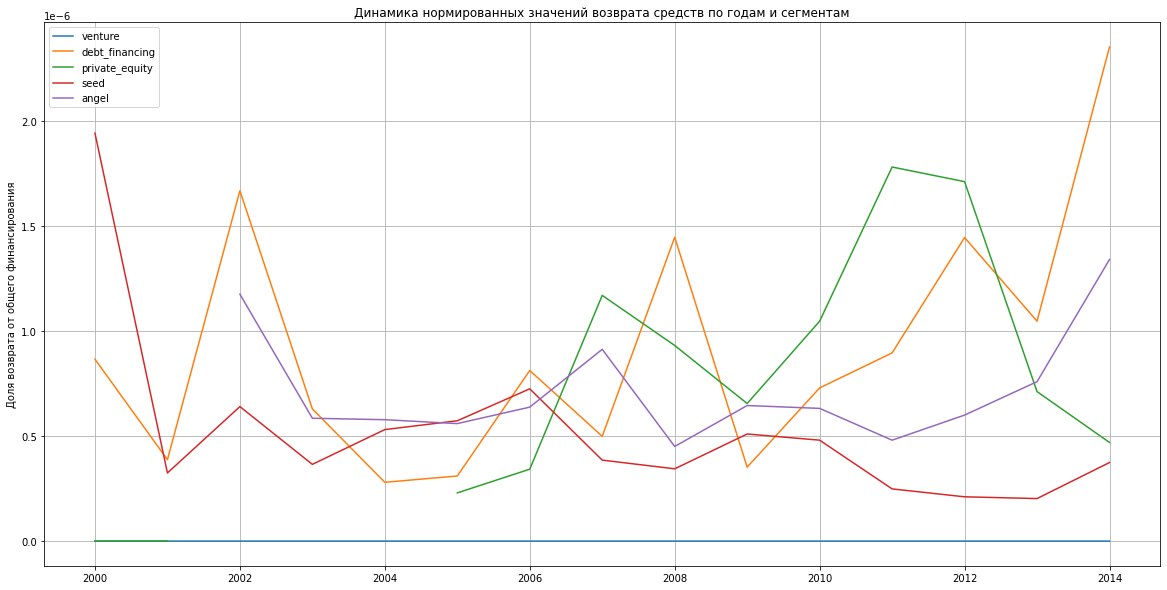

In [157]:
return_ratio.plot(kind='line',
                  figsize=(20, 10))
                 
plt.title('Динамика нормированных значений возврата средств по годам и сегментам')
plt.xlabel('')
plt.ylabel('Доля возврата от общего финансирования')

plt.grid()
plt.show()

Наиболее устойчивый рост наблюдается у долгового финансирования ('debt_financing').


## Итоговый вывод и рекомендации

**На основе исследовательского анализа данных можно сказать,** что наиболее благоприятная отрасль для инвестиций - это 'software'; А самый выгодный способ финансирования - это венчурные инвестиции ('venture').

1. 
В рамках исследования были проанализированы данные двух датасетов: `cb_investments.csv` и `cb_returns.csv`. Они состояли из информации о компаниях + состоявшемся финансировании и сведений об объёмах возвратов по годам и типам финансирования в миллионах долларов.

2.
В ходе работы были выполнены следующие шаги:
**- Загрузить предоставленные данные и познакомиться с ними:**
В датасете `cb_investments.csv` были предоставлены объемные данные, требующие частичной фильтрации и корректировки. Датасет `cb_returns.csv` был полностью готов к работе.
**- Выполнить предобработку данных: выявить неточности и скорректировать их для дальнейшего анализа:**
В датасете `cb_investments.csv` были скорректированы названия столбцов, часть типов данных и неточности в значениях столбцов. Были удалены полные дубликаты в данных и пропуски в `funding_total_usd`. Также, заполнены пропуски в столбце `mid_funding_at` на основании значений `first_funding_at` и `last_funding_at`. Всего было обработано 13387 строк - это 25% от общего их количества.
**- Провести исследовательский анализ данных:**
 * Все компании были разделены на три группы: `единичное финансирование`, `срок финансирования до года`, `срок финансирования более года`. Больше всего компаний с еденичным финансированием, а больше всего средств привлекли компании со сроком финансирования блее года.
 * Была выполнена классификация сегментов рынка на массовые, средние и нишевые. Больше всего компаний относится к массовому сегменту.
* Определили типичные и аномальные значения объёмов финансирования. Наиболее типичным размером финансирования являются взносы от 1000000 до 10000000. Но также в порядке вещей и взносы до 25000000 долларов. Выбивающийся размер финансирования начинается в районе 100000 и выше. Оставили в датасете данные только об определённых компаниях. Они получали финансирование в годы, когда было зафиксировано 50 или более раундов финансирования. Так оставили данные за 14 лет (2000-2014 гг.).
* Сравнили популярность и объёмы разных типов финансирования. По популярности и сумме возвратов инвестиций лидером являются венчурные инвестиции ('venture').
* Проанализировали динамику раундов и объёмов инвестиций по годам, а также изменения в массовых сегментах рынка. С 2000-ого года количество выделяемого финансирования с каждым годом становилось все меньше и к 2014 году достигло своего минимума за все время. Также, количество раундов финансирования c 2012-ого года резко пошло на спад и в 2014 году достигло уровня 2005 года.
* Рассчитали долю возврата средств для разных типов финансирования. Самый стабильный рост показывает сегмент 'apps', а наиболее устойчивый рост наблюдается у долгового финансирования ('debt_financing').